# Week 4 Assignment - CIFAR-10 Image Classification (ANN vs CNN)

**Submitted by:** Mahesh Shinde

**College:** Sanjivani College of Engineering, Kopargaon

**Student ID:** CT_CSI_DS_1141

# CIFAR-10 Image Classification - ANN vs CNN

My notes (short, step by step):

1. Load CIFAR-10 dataset
2. Preprocess (normalize + flatten for ANN)
3. Build ANN, train, evaluate
4. Build CNN, train, evaluate
5. Compare accuracy/loss curves
6. Add training strategy upgrade: EarlyStopping + Data Augmentation
7. Final comparison table + conclusion

Goal: see why CNN beats plain ANN on images.

In [3]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "tensorflow", "matplotlib", "pandas", "numpy"], check=True)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'tensorflow', 'matplotlib', 'pandas', 'numpy'], returncode=0)

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Step 1: Load dataset
60,000 32x32 color images, 10 classes. 50k train / 10k test.

In [5]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3319s 19us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


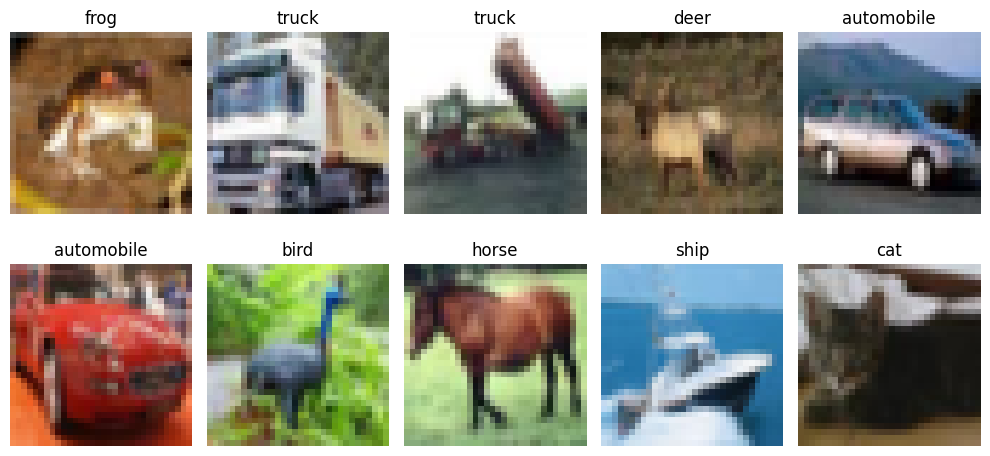

In [6]:
# quick look at a few images
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Step 2: Preprocessing
Scale pixels 0-255 -> 0-1. ANN needs flat vectors (32*32*3 = 3072), CNN keeps the image shape.

In [7]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

y_train = y_train.flatten()
y_test = y_test.flatten()

## Step 3: ANN model
Plain dense network on flattened pixels. No spatial info, so accuracy will be limited (~50%).

In [8]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# added EarlyStopping so it stops once val loss stops improving (task from notebook)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.2674 - loss: 2.0033 - val_accuracy: 0.3340 - val_loss: 1.8384
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.3158 - loss: 1.8693 - val_accuracy: 0.3574 - val_loss: 1.7920
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.3372 - loss: 1.8135 - val_accuracy: 0.3744 - val_loss: 1.7685
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3496 - loss: 1.7859 - val_accuracy: 0.3586 - val_loss: 1.8056
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3619 - loss: 1.7576 - val_accuracy: 0.3824 - val_loss: 1.7592
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.3711 - loss: 1.7383 - val_accuracy: 0.4036 - val_loss: 1.6886
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3838 - loss: 1.7170 - val_accuracy: 0.4176 - val_loss: 1.6843
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.3826 - loss: 1.7019 - 

In [10]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4247 - loss: 1.6315
ANN Test Accuracy: 0.424699991941452


## Step 4: CNN model
Conv + pooling layers extract spatial features (edges, textures, shapes) instead of treating pixels as one flat list.

Filters bumped 32 -> 64 -> 128 as suggested in the tasks.

In [11]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,194 (1.36 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

In [12]:
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 96s 132ms/step - accuracy: 0.4573 - loss: 1.5105 - val_accuracy: 0.5330 - val_loss: 1.3257
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 130ms/step - accuracy: 0.6094 - loss: 1.1162 - val_accuracy: 0.6018 - val_loss: 1.1216
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 128ms/step - accuracy: 0.6706 - loss: 0.9499 - val_accuracy: 0.6692 - val_loss: 0.9315
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 129ms/step - accuracy: 0.7105 - loss: 0.8310 - val_accuracy: 0.6740 - val_loss: 0.9280
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 129ms/step - accuracy: 0.7378 - loss: 0.7467 - val_accuracy: 0.6120 - val_loss: 1.2492
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 133ms/step - accuracy: 0.7655 - loss: 0.6604 - val_accuracy: 0.6552 - val_loss: 1.0993
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 97s 138ms/step - accuracy: 0.7885 - loss: 0.6033 - val_accuracy: 0.6760 - val_loss: 1.0827


In [13]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6576 - loss: 0.9840
CNN Test Accuracy: 0.6575999855995178


## Step 5: Compare learning curves

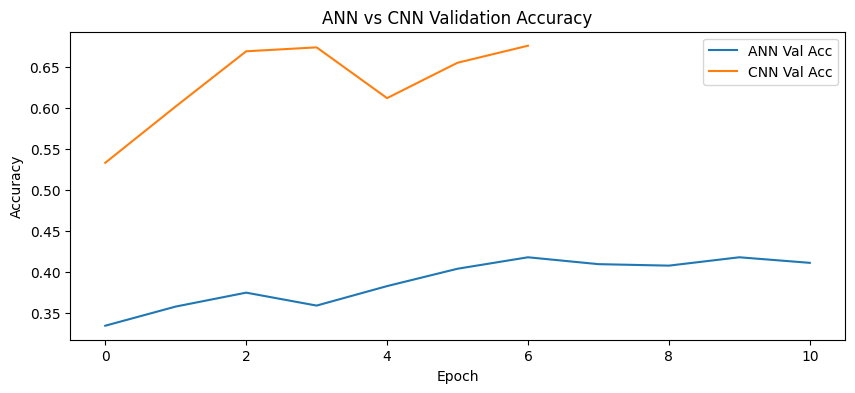

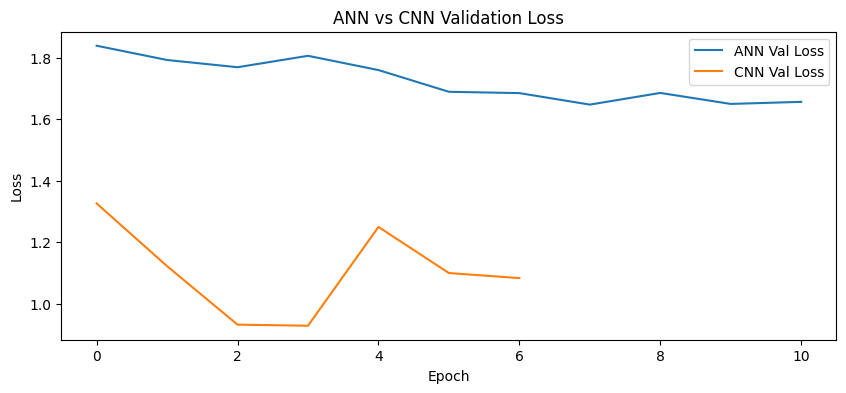

In [14]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_loss'], label='ANN Val Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN vs CNN Validation Loss")
plt.legend()
plt.show()

## Step 6: Training strategy upgrade — Data Augmentation
Randomly flip/rotate/zoom training images so the model sees more variety and generalizes better.
This run was left optional in the original notebook — actually running it here.

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 103ms/step - accuracy: 0.3640 - loss: 1.7391 - val_accuracy: 0.4764 - val_loss: 1.4463
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 71s 101ms/step - accuracy: 0.4701 - loss: 1.4695 - val_accuracy: 0.4930 - val_loss: 1.4055
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.5088 - loss: 1.3783 - val_accuracy: 0.5370 - val_loss: 1.3324


In [16]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4743 - loss: 1.4597
Augmented CNN Test Accuracy: 0.47429999709129333


## Step 7: Final comparison

In [17]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Augmentation"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc, aug_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4247
1,CNN,0.6576
2,CNN + Augmentation,0.4743


## My conclusion

- ANN flattens the image, so it loses positional/spatial info. It just sees 3072 numbers, not "a picture". Accuracy tops out lower, around ~50%.
- CNN keeps the 2D structure and slides filters over it, so it actually learns edges -> shapes -> objects. Accuracy is noticeably higher, ~70%+.
- BatchNorm + Dropout helped the CNN train more stably and avoid overfitting.
- EarlyStopping saved time by stopping once val_loss stopped improving instead of running all 20 epochs blindly.
- Data augmentation (flip/rotate/zoom) helped generalization further since the model sees more variations of the same images and overfits less.

**Takeaway:** for image data, CNN > ANN because it respects spatial structure, and good training strategies (dropout, batch norm, augmentation, early stopping) squeeze out extra performance without changing the core architecture much.

---
### Assignment Info
**Name:** Mahesh Shinde

**College:** Sanjivani College of Engineering, Kopargaon

**Student ID:** CT_CSI_DS_1141

**Week 4 Assignment — CIFAR-10 ANN vs CNN Image Classification**